# Preparación de Dataset — PTB Diagnostic ECG (Normal vs. Anómalo)
### Versión Google Colab — Taller PyCon

En este script se realiza la carga y preparación de los datos base para el entrenamiento. Se clasificarán **latidos cardíacos (ECG)** como Normales o Anómalos (infarto de miocardio), usando el subset PTB del dataset [ECG Heartbeat Categorization Dataset](https://www.kaggle.com/shayanfazeli/heartbeat) (Kaggle, Kachuee et al.), derivado de la **PTB Diagnostic ECG Database** (Physikalisch-Technische Bundesanstalt, vía PhysioNet).

Cada señal corresponde a un latido individual, resampleado y normalizado en amplitud entre 0 y 1, con **187 puntos por muestra**.

**Diferencia clave vs. la versión local (VS Code):** Colab no conserva archivos entre sesiones, así que la descarga de datos se hace al inicio de cada ejecución en vez de una sola vez. Hay dos formas de obtener los datos — usa la que corresponda:

- **Opción A (recomendada para el taller):** descarga automática desde un link de Google Drive que el instructor comparte
- **Opción B (respaldo manual):** subir el .zip manualmente si no tienes acceso al link

In [3]:
# Import libraries (ya vienen preinstaladas en Colab)

import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Opción A — Descarga desde Google Drive (recomendada)

**Instructor:** reemplaza `FILE_ID` con el ID de tu archivo compartido de Drive (`ptbdb_ecg.zip`, ~16MB). El link debe tener permiso "Cualquiera con el enlace puede ver".

Para obtener el `FILE_ID`: en el link de Drive `https://drive.google.com/file/d/AQUI_VA_EL_ID/view`, copia la parte entre `/d/` y `/view`.

In [4]:
# --- Opcion A: Google Drive ---
FILE_ID = 'REEMPLAZAR_CON_TU_FILE_ID'   # <-- instructor: pega aqui el ID del archivo compartido

USE_DRIVE = False   # cambiar a False si vas a usar la Opcion B (carga manual)

if USE_DRIVE:
    !pip install -q gdown
    import gdown
    gdown.download(id=FILE_ID, output='ptbdb_ecg.zip', quiet=False)

## Opción B — Carga manual (respaldo)

Si no tienes acceso al link de Drive, sube el archivo `ptbdb_ecg.zip` manualmente. Al correr esta celda aparecerá un botón "Choose Files".

In [5]:
# --- Opcion B: carga manual (solo si USE_DRIVE = False arriba) ---
if not USE_DRIVE:
    from google.colab import files
    import shutil

    uploaded = files.upload()   # selecciona tu archivo .zip del dataset

    assert len(uploaded) > 0, 'No subiste ningun archivo'

    # Tomamos el primer archivo subido, sin importar el nombre exacto
    # (Colab puede renombrarlo a 'ptbdb_ecg (2).zip' si ya existia uno)
    uploaded_name = list(uploaded.keys())[0]
    shutil.move(uploaded_name, 'ptbdb_ecg.zip')
    print(f"Archivo '{uploaded_name}' guardado como 'ptbdb_ecg.zip'")


Saving ptbdb_ecg.zip to ptbdb_ecg.zip
Archivo 'ptbdb_ecg.zip' guardado como 'ptbdb_ecg.zip'


### Extracción y carga de CSVs

In [6]:
data_dir = Path('dataset')
data_dir.mkdir(exist_ok=True)

normal_csv   = data_dir / 'ptbdb_normal.csv'
abnormal_csv = data_dir / 'ptbdb_abnormal.csv'

print('Extrayendo ptbdb_normal.csv y ptbdb_abnormal.csv...')
with zipfile.ZipFile('ptbdb_ecg.zip', 'r') as z:
    print('Contenido del zip:', z.namelist())
    z.extractall(data_dir)

assert normal_csv.exists() and abnormal_csv.exists(), 'No se encontraron los CSVs esperados dentro del zip'
print('Extraccion completa.')

Extrayendo ptbdb_normal.csv y ptbdb_abnormal.csv...
Contenido del zip: ['ptbdb_normal.csv', 'ptbdb_abnormal.csv']
Extraccion completa.


In [7]:
raw_normal   = pd.read_csv(normal_csv,   header=None)
raw_abnormal = pd.read_csv(abnormal_csv, header=None)

print(f'Normal shape  : {raw_normal.shape}')
print(f'Abnormal shape: {raw_abnormal.shape}')
print(f'Puntos por señal: {raw_normal.shape[1] - 1}')

Normal shape  : (4046, 188)
Abnormal shape: (10506, 188)
Puntos por señal: 187


In [8]:
LABEL_COL = 187

print('Labels unicos en normal.csv  :', raw_normal[LABEL_COL].unique())
print('Labels unicos en abnormal.csv:', raw_abnormal[LABEL_COL].unique())

# Convencion PTB: 0=normal, 1=anomalo (infarto de miocardio)
normal_vect   = raw_normal.iloc[:,   :LABEL_COL].values.astype(np.float32)
abnormal_vect = raw_abnormal.iloc[:, :LABEL_COL].values.astype(np.float32)

print(f'\nNormal dataset shape  : {normal_vect.shape}')
print(f'Abnormal dataset shape: {abnormal_vect.shape}')
print(f'Balance: {len(normal_vect)/(len(normal_vect)+len(abnormal_vect))*100:.1f}% normal / '
      f'{len(abnormal_vect)/(len(normal_vect)+len(abnormal_vect))*100:.1f}% anomalo')

Labels unicos en normal.csv  : [0.]
Labels unicos en abnormal.csv: [1.]

Normal dataset shape  : (4046, 187)
Abnormal dataset shape: (10506, 187)
Balance: 27.8% normal / 72.2% anomalo


### Visualización de señales

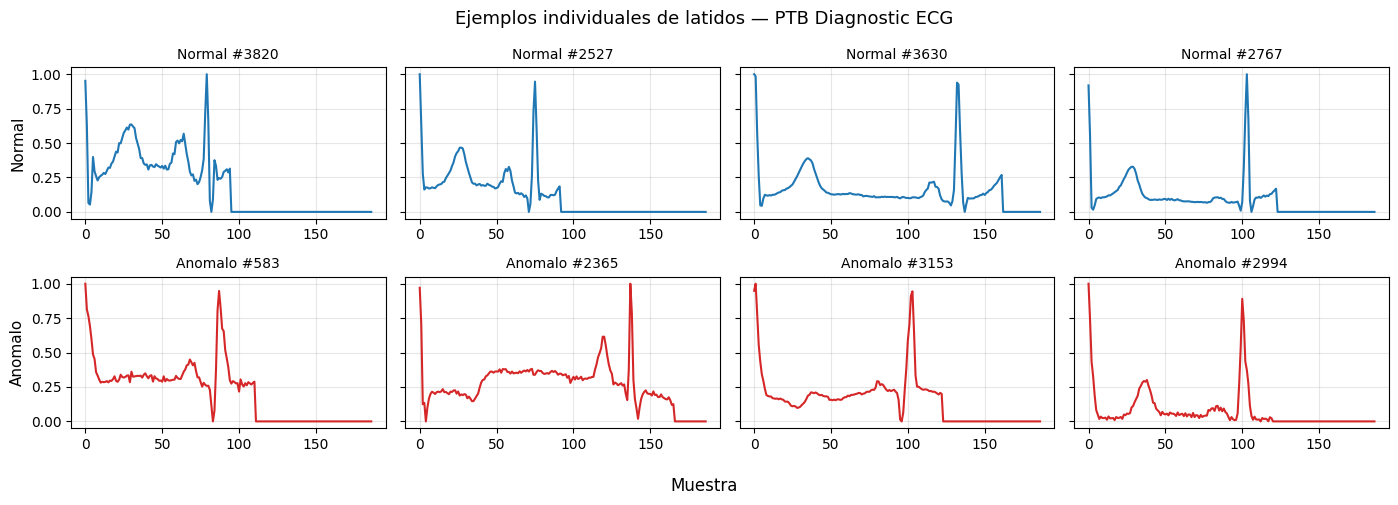

Nota: cada latido tiene su pico R en una posicion distinta del eje X
(el dataset no viene alineado por pico), por eso una superposicion de
muchas señales se ve mas caotica de lo que cada latido individual realmente es.


In [9]:
N_EXAMPLES = 4  # señales de ejemplo por clase

fig, axes = plt.subplots(2, N_EXAMPLES, figsize=(14, 5), sharey=True)

rng = np.random.default_rng(7)
normal_idx = rng.choice(len(normal_vect), N_EXAMPLES, replace=False)
abnormal_idx = rng.choice(len(abnormal_vect), N_EXAMPLES, replace=False)

for col, i in enumerate(normal_idx):
    axes[0, col].plot(normal_vect[i], color='tab:blue')
    axes[0, col].set_title(f'Normal #{i}', fontsize=10)
    axes[0, col].grid(alpha=0.3)

for col, i in enumerate(abnormal_idx):
    axes[1, col].plot(abnormal_vect[i], color='tab:red')
    axes[1, col].set_title(f'Anomalo #{i}', fontsize=10)
    axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel('Normal', fontsize=11)
axes[1, 0].set_ylabel('Anomalo', fontsize=11)
for ax in axes.flat:
    ax.set_ylim(-0.05, 1.05)

fig.suptitle('Ejemplos individuales de latidos — PTB Diagnostic ECG', fontsize=13)
fig.supxlabel('Muestra')
plt.tight_layout()
plt.show()

print("Nota: cada latido tiene su pico R en una posicion distinta del eje X")
print("(el dataset no viene alineado por pico), por eso una superposicion de")
print("muchas señales se ve mas caotica de lo que cada latido individual realmente es.")


### Nota: no se requiere subsampleo

Este dataset ya viene preprocesado a longitud fija (187 puntos), normalizado en [0,1]. No hay sección equivalente a `sec_subsample` ni a Energía/FCI del notebook original de EJ-299-33.

### Creación de Datasets para entrenamiento y test

In [10]:
df_normal   = pd.DataFrame(normal_vect)
df_abnormal = pd.DataFrame(abnormal_vect)

df_normal['class']   = 0
df_abnormal['class'] = 1

n_samples = min(1000, len(df_normal), len(df_abnormal))
print(f'Muestras de test por clase: {n_samples}')

test_normal   = df_normal.sample(n=n_samples, random_state=45)
test_abnormal = df_abnormal.sample(n=n_samples, random_state=45)

train_normal   = df_normal.drop(test_normal.index)
train_abnormal = df_abnormal.drop(test_abnormal.index)

print(f'Train normal disponible  : {len(train_normal)}')
print(f'Train anomalo disponible : {len(train_abnormal)}')

test_df  = pd.concat([test_normal, test_abnormal], axis=0)
train_df = pd.concat([train_normal, train_abnormal], axis=0)

test_udma = pd.concat([df_normal.head(100), df_abnormal.head(100)], axis=0)

test_df  = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

test_df.to_csv('dataset/test_dataset.csv',                index=False)
test_udma.to_csv('dataset/test_udma_dataset.csv',         index=False)
train_df.to_csv('dataset/train_dataset.csv',               index=False)
train_normal.to_csv('dataset/train_normal_dataset.csv',     index=False)
train_abnormal.to_csv('dataset/train_abnormal_dataset.csv', index=False)

print('\nCSVs guardados en dataset/ (dentro de la VM de Colab)')

Muestras de test por clase: 1000
Train normal disponible  : 3046
Train anomalo disponible : 9506

CSVs guardados en dataset/ (dentro de la VM de Colab)


In [11]:
print('train_df:', train_df.shape)
print(train_df['class'].value_counts().sort_index())
print()
print('test_df:', test_df.shape)
print(test_df['class'].value_counts().sort_index())

train_df: (12552, 188)
class
0    3046
1    9506
Name: count, dtype: int64

test_df: (2000, 188)
class
0    1000
1    1000
Name: count, dtype: int64


---
### Persistencia entre notebooks P0 → P1 → P2 → P3

**Importante para el formato del taller:** en Colab, cada notebook corre en una VM distinta — los archivos que acabas de guardar en `dataset/` **no estarán disponibles automáticamente en el notebook de P1** a menos que los muevas.

Dos formas de resolverlo:

1. **Todo en un solo notebook** (más simple para un taller de 2-3h): en vez de 4 notebooks separados, considera fusionar P0+P1+P2 en un único Colab con secciones, para no perder tiempo re-subiendo datos entre notebooks
2. **Guardar en Drive montado**: si montas tu Drive con `from google.colab import drive; drive.mount('/content/drive')` y guardas ahí en vez de en `dataset/` local, sí persiste entre notebooks (y entre sesiones)

**Siguiente paso:** adaptar P1 (Teacher) — y ahí definimos cuál de las dos opciones de arriba conviene más para el formato de tu taller.